# Gauge study - river reaches with same-river gauge triplets

**Fully self-contained**: it does **not** import `study_area.py` or `select_areas.py`. All logic is inlined.

**Scope (SWOT & FIMBench are NOT considered).** The search sweeps **every CONUS SWORD river reach** and keeps
the ones that have USGS gauges on the **same river channel**:

* **on-reach gauge**   - a gauge whose nearest SWORD centerline *is* this reach (discharge Q)
* **upstream gauge**   - nearest gauge on the same river, on *another* reach further from the outlet
* **downstream gauge** - nearest gauge on the same river, on *another* reach nearer the outlet

There is **no SWOT-observation requirement and no FIMBench requirement** - reaches are candidates purely because
they carry same-river gauges.

**A reach qualifies only if its gauges can form a water-surface slope over it** - one of:
(1) bracketed by an upstream **and** a downstream gauge; (2) **≥2 gauges on the reach**; (3) one on-reach gauge
**plus** an upstream **or** downstream gauge. A lone on-reach gauge, or a single distant up/down gauge (which is
really another reach's on-reach gauge, exactly aligned with it), is rejected. The reported station span must be
**≤ 50 km**.

**Same river, not tributary.** Two guards: (1) the reach chain always follows the largest-drainage (`facc`)
branch at confluences, so ascending can never climb a tributary; (2) a snapped gauge is kept only if its USGS
station-name water-body token matches the reach's river (e.g. *Nescopeck Creek* rejected on the *Susquehanna*).

The upstream/downstream gauges therefore always sit on **other reaches of the same river**, never on the study
reach itself (the on-reach gauge).

**Outputs (self-contained).** The notebook creates an `output_gauge/` folder and writes everything there - tables to `output_gauge/table/`, figures to `output_gauge/fig/`. It imports no project modules; running it top-to-bottom reproduces every table and figure. Section 9 additionally screens each station for a USGS **stage** (gage-height) time series and writes `gauge_stage_labeled.csv` + `gauge_stage_cleaned.csv`.

**Reach maps show the whole gauged path.** Each map draws the *study reach* (cyan) **and** the same-river reaches that connect the upstream and downstream gauges (a second blue), so the picture is the continuous river between the bracketing gauges - not just the isolated middle reach.

## 1 · Setup - imports, paths, parameters

In [1]:
import os, sys, re, warnings
os.environ.pop("PROJ_DATA", None); os.environ.pop("PROJ_LIB", None)   # keep pyogrio/PROJ state clean
warnings.filterwarnings("ignore")
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd
import geopandas as gpd, pyogrio
import matplotlib.pyplot as plt

def _repo_root():
    """Repository root, resolved portably so the notebook runs after `git clone` (from the repo root or a
    subfolder): the SLOPE_ROOT environment variable, else the nearest parent with a `.slope_root` marker or a
    `data/` folder."""
    env = os.environ.get("SLOPE_ROOT")
    if env: return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand/".slope_root").exists() or (cand/"data").is_dir(): return cand
    return here
ROOT = _repo_root(); DATA = ROOT/"data"
SWORD_GPKG = DATA/"SWORD_v17b_gpkg"/"na_sword_reaches_v17b.gpkg"      # topology + geometry
USGS_GAGES_GPKG = DATA/"usgs_gages.gpkg"                             # active USGS discharge sites
PAIRED_CSV = DATA/"paired_reach_SWOT_gage"/"paired_reach_SWOT_gage.csv"   # extra gauge coverage

# outputs -> output_gauge/
OUT = ROOT/"output_gauge"; FIG = OUT/"fig"; TAB = OUT/"table"
for _d in (FIG, TAB): _d.mkdir(parents=True, exist_ok=True)

def savefig(fig, path, dpi=300, **kw):
    """Single figure-export helper: save `fig` at 300 dpi as BOTH a raster .png and a vector .svg."""
    p = Path(path); kw.setdefault("bbox_inches", "tight")
    fig.savefig(p.with_suffix(".png"), dpi=dpi, **kw); fig.savefig(p.with_suffix(".svg"), **kw)
    return p
CAND_CSV = TAB/"study_area_gauge_candidates.csv"                     # <- this notebook's table output

CONUS_BBOX = (-125.0, 24.0, -66.5, 49.5)
RIVER_TYPE = 1            # SWORD type 1 == river
GAGE_SNAP_M = 1000.0      # a gauge is "on" a reach if within 1000 m of the SWORD reach centerline
CHAIN_MAX_KM = 60.0       # search this far up/down the same river
CHAIN_MAX_HOPS = 40
MERGE_FACC_RATIO = 1.8    # downstream: an unnamed reach gaining >1.8x drainage has merged into a bigger river
SPAN_MAX_KM = 50.0        # reject a reach whose reported gauge span exceeds this (km)
print("paths ok:", SWORD_GPKG.exists(), USGS_GAGES_GPKG.exists(), "| outputs ->", OUT.relative_to(ROOT))

paths ok: True True | outputs -> output_gauge


## 2 · The gauge-search engine (inlined)

Ported from the curated 3-gauge method (`find_reaches3.py` / `work6_3DHRS.ipynb`) and generalised to every
CONUS river reach. Kept inline so the notebook needs no external module.

In [2]:
def log(m): print(f"[gauge_study] {m}", flush=True)

def _norm_name(s):
    s = str(s).strip().upper()
    return "" if s in ("NODATA", "NAN", "NONE", "") else s

# generic water-body / locator words dropped so only the DISTINCTIVE river name survives
_STOP = {"river","rv","r","creek","ck","cr","canal","cnl","bayou","byu","brook","run","slough","sl","ditch",
         "draw","wash","branch","br","fork","fk","north","south","east","west","n","s","e","w","ne","nw","se",
         "sw","of","the","at","near","nr","above","abv","ab","below","blw","bl","upper","lower","little","big",
         "main","stem","old","new","and","de","la","el","los","las","rio","st","ft","usa"}

def _sig(name):
    "Distinctive river-name tokens: 'North Branch Susquehanna River'->{susquehanna}; 'Nescopeck Creek'->{nescopeck}."
    txt = str(name).lower()
    for sep in (" at "," near "," nr "," above "," abv "," below "," blw "," bl "): txt = txt.split(sep)[0]
    return {t for t in re.findall(r"[a-z]+", txt) if len(t) > 2 and t not in _STOP}

def _reach_river_name(r, reaches, on_g, gname):
    n = _norm_name(reaches.at[r, "river_name"])
    if n: return n.title()
    if on_g is not None:
        nm = str(gname.get(on_g[0], ""))
        for sep in (" AT "," NEAR "," NR "," ABOVE "," ABV "," BELOW "," BLW "): nm = nm.upper().split(sep)[0]
        if nm.strip(): return nm.strip().title()
    return ""

def _tokens(v):
    "Parse a SWORD rch_id_up/rch_id_dn field (space-delimited ids) into a list of str ids."
    if v is None or (isinstance(v, float) and np.isnan(v)): return []
    out = []
    for t in str(v).replace(",", " ").split():
        t = t.split(".")[0]
        if t.isdigit() and t != "0": out.append(t)
    return out

def load_gauges():
    "Union of active USGS discharge gages + SWOT-paired gages -> GeoDataFrame(site_no, station_nm, geometry)."
    frames = []
    if USGS_GAGES_GPKG.exists():
        g = gpd.read_file(USGS_GAGES_GPKG)[["site_no","station_nm","geometry"]]; g["site_no"] = g.site_no.astype(str)
        frames.append(g)
    if PAIRED_CSV.exists():
        p = pd.read_csv(PAIRED_CSV, usecols=["gage_id","gage_name","gage_latitude","gage_longitude"],
                        dtype={"gage_id": str}, low_memory=False).drop_duplicates("gage_id")
        p["gage_latitude"] = pd.to_numeric(p.gage_latitude, errors="coerce")
        p["gage_longitude"] = pd.to_numeric(p.gage_longitude, errors="coerce")
        p = p.dropna(subset=["gage_latitude","gage_longitude"])
        frames.append(gpd.GeoDataFrame({"site_no": p.gage_id.astype(str), "station_nm": p.gage_name},
                      geometry=gpd.points_from_xy(p.gage_longitude, p.gage_latitude), crs="EPSG:4326"))
    gauges = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), geometry="geometry", crs="EPSG:4326")
    return gauges.dropna(subset=["geometry"]).drop_duplicates("site_no").reset_index(drop=True)

def _order_on_reach(reach, on, chain, LINE, XY):
    "Order the on-reach gauges (tuples with gx,gy in 5070) upstream-first along the reach centerline."
    from shapely.geometry import Point
    line = LINE.get(reach)
    if line is None: return sorted(on, key=lambda g: g[2])
    cs = list(line.coords); ep0, ep1 = Point(cs[0]), Point(cs[-1])
    up_nbs = [cr for cr in chain if chain[cr] > 0]; dn_nbs = [cr for cr in chain if chain[cr] < 0]
    up_end = None
    if up_nbs:
        u = XY.get(min(up_nbs, key=lambda cr: chain[cr]))
        if u is not None: up_end = ep0 if ep0.distance(u) <= ep1.distance(u) else ep1
    if up_end is None and dn_nbs:
        d = XY.get(max(dn_nbs, key=lambda cr: chain[cr]))
        if d is not None:
            dn_end = ep0 if ep0.distance(d) <= ep1.distance(d) else ep1
            up_end = ep1 if dn_end is ep0 else ep0
    if up_end is None: up_end = ep0
    return sorted(on, key=lambda g: Point(g[3], g[4]).distance(up_end))

In [3]:
def same_river_chain(reach, UP, DN, DIST, FACC, NAME, max_km=CHAIN_MAX_KM, max_hops=CHAIN_MAX_HOPS):
    "Reach ids on the SAME river within +/-max_km of `reach`: {reach_id: signed_along_km} (+up, -down, 0 self)."
    d0 = DIST.get(reach, np.nan); name0 = NAME.get(reach, ""); chain = {reach: 0.0}
    if not np.isfinite(d0): return chain
    def pick(cands):
        cands = [c for c in cands if c in DIST]
        if not cands: return None
        if name0:
            same = [c for c in cands if NAME.get(c, "") == name0]
            if same: return max(same, key=lambda c: FACC.get(c, -1.0))
        return max(cands, key=lambda c: FACC.get(c, -1.0))     # main stem == largest drainage
    cur = reach                                                 # upstream: largest-facc parent -> never a tributary
    for _ in range(max_hops):
        nxt = pick(UP.get(cur, []))
        if nxt is None or nxt in chain: break
        along = abs(DIST.get(nxt, d0) - d0) / 1000.0
        if along > max_km: break
        if name0 and NAME.get(nxt, "") and NAME.get(nxt, "") != name0: break
        chain[nxt] = +along; cur = nxt
    cur = reach; fprev = FACC.get(reach, np.nan)                # downstream
    for _ in range(max_hops):
        nxt = pick(DN.get(cur, []))
        if nxt is None or nxt in chain: break
        along = abs(DIST.get(nxt, d0) - d0) / 1000.0
        if along > max_km: break
        nname = NAME.get(nxt, ""); fn = FACC.get(nxt, np.nan)
        if name0 and nname and nname != name0: break                                     # merged into another river
        if (not name0) and np.isfinite(fprev) and np.isfinite(fn) and fprev > 0 and fn > fprev*MERGE_FACC_RATIO: break
        chain[nxt] = -along; cur = nxt; fprev = fn
    return chain

In [4]:
def gauge_study():
    "Every CONUS SWORD river reach with a same-river up/on/down gauge. Returns one row per such reach."
    log(f"Reading SWORD v17b reaches: {SWORD_GPKG.name}")
    sword = pyogrio.read_dataframe(SWORD_GPKG, columns=["reach_id","x","y","width","reach_len","slope",
        "river_name","type","dist_out","facc","rch_id_up","rch_id_dn"])
    sword = sword.set_crs(4326, allow_override=True); sword["reach_id"] = sword.reach_id.astype("int64").astype(str)
    UP = {r: _tokens(u) for r, u in zip(sword.reach_id, sword.rch_id_up)}
    DN = {r: _tokens(d) for r, d in zip(sword.reach_id, sword.rch_id_dn)}
    DIST = dict(zip(sword.reach_id, pd.to_numeric(sword.dist_out, errors="coerce")))
    FACC = dict(zip(sword.reach_id, pd.to_numeric(sword.facc, errors="coerce")))
    NAME = {r: _norm_name(n) for r, n in zip(sword.reach_id, sword.river_name)}

    # candidate universe: ALL river reaches in CONUS (no SWOT, no FIMBench).
    # NB bracket access: GeoDataFrame.type is the geometry-type property, not the "type" column.
    lon0, lat0, lon1, lat1 = CONUS_BBOX
    cand = sword[(sword["type"] == RIVER_TYPE) &
                 sword["x"].between(lon0, lon1) & sword["y"].between(lat0, lat1)].copy()
    reaches = cand.set_index("reach_id")
    log(f"  CONUS SWORD river reaches to search: {len(reaches):,}")

    # snap every gauge to its single nearest SWORD reach (tributary-aware)
    log(f"Snapping USGS gauges to nearest SWORD reach (<= {GAGE_SNAP_M:.0f} m) ...")
    gauges = load_gauges().to_crs("EPSG:5070"); sword_m = sword[["reach_id","geometry"]].to_crs("EPSG:5070")
    snap = gpd.sjoin_nearest(gauges, sword_m, how="inner", max_distance=GAGE_SNAP_M,
                             distance_col="snap_m").sort_values("snap_m").drop_duplicates("site_no")
    snap["gx"] = snap.geometry.x; snap["gy"] = snap.geometry.y
    log(f"  {len(snap):,} of {len(gauges):,} gauges snap onto a SWORD channel")
    GNAME = snap.set_index("site_no")["station_nm"].astype(str).to_dict()
    reach2g = defaultdict(list)
    for _, g in snap.iterrows(): reach2g[str(g.reach_id)].append((str(g.site_no), float(g.snap_m), float(g.gx), float(g.gy)))
    gauged = set(reach2g)                                       # reaches that carry >=1 gauge
    LINE = dict(zip(sword_m.reach_id, sword_m.geometry)); XY = dict(zip(sword_m.reach_id, sword_m.geometry.centroid))

    rows = []; n_trib = 0
    for r in reaches.index:
        chain = same_river_chain(r, UP, DN, DIST, FACC, NAME)
        if gauged.isdisjoint(chain):                           # fast skip: no gauge anywhere on this river segment
            continue
        gset = [(site, along, sm, gx, gy) for cr, along in chain.items() for site, sm, gx, gy in reach2g.get(cr, [])]
        gset = list({g[0]: g for g in gset}.values())
        ref = _sig(reaches.at[r, "river_name"])
        onr = [g for g in gset if g[1] == 0.0]
        if onr: ref |= _sig(GNAME.get(min(onr, key=lambda g: g[2])[0], ""))
        if ref:                                                # keep only same-river (not tributary) gauges
            kept = [g for g in gset if (_sig(GNAME.get(g[0], "")) & ref) or not _sig(GNAME.get(g[0], ""))]
            n_trib += len(gset) - len(kept); gset = kept
        if not gset:                                           # no same-river gauge -> not a candidate
            continue
        on = [g for g in gset if g[1] == 0.0]; nb_up = [g for g in gset if g[1] > 0.0]; nb_dn = [g for g in gset if g[1] < 0.0]
        on_count = len(on)
        if on_count >= 2:                                       # all-on-reach: order gauges along the reach
            oss = _order_on_reach(r, on, chain, LINE, XY); up_g, dn_g = oss[0], oss[-1]
            on_g = oss[len(oss)//2] if on_count >= 3 else None; cluster = on
        else:
            on_g = on[0] if on else None
            up_g = min(nb_up, key=lambda g: g[1]) if nb_up else None
            dn_g = max(nb_dn, key=lambda g: g[1]) if nb_dn else None
            cluster = [g for g in (up_g, on_g, dn_g) if g]
        if len(cluster) >= 2:
            xy = np.array([[g[3], g[4]] for g in cluster])
            span_km = float(np.max(np.linalg.norm(xy[:, None, :] - xy[None, :, :], axis=-1))/1000.0)
        else: span_km = 0.0
        # KEEP a valid slope-capable configuration: bracketed (up AND dn), OR >=2 on-reach gauges, OR 1
        # on-reach gauge + an up/down neighbour -- AND the station span <= SPAN_MAX_KM. A lone on-reach
        # gauge, or a lone distant up/down gauge, cannot form a water-surface slope over the reach.
        if not (((up_g and dn_g) or (on_count >= 1 and (up_g or dn_g))) and span_km <= SPAN_MAX_KM):
            continue
        # every SAME-RIVER reach linking the upstream gauge to the downstream gauge: the study reach
        # (along 0) plus the reaches that carry / bridge the bracketing gauges. Lets the maps draw the
        # whole continuous river between the two stations, not only the middle reach.
        lo = dn_g[1] if dn_g else 0.0; hi = up_g[1] if up_g else 0.0
        connectors = [cr for cr, a in chain.items() if lo - 1e-6 <= a <= hi + 1e-6]
        rows.append(dict(reach_id=r, n_gauges=len(cluster),
            upstream_gauge_id=up_g[0] if up_g else "", onreach_gauge_id=on_g[0] if on_g else "",
            downstream_gauge_id=dn_g[0] if dn_g else "", max_span_km=round(span_km, 2),
            river_name=_reach_river_name(r, reaches, on_g, GNAME),
            lat=round(float(reaches.at[r, "y"]), 5), lon=round(float(reaches.at[r, "x"]), 5),
            up_dist_km=round(up_g[1], 2) if up_g else np.nan, dn_dist_km=round(-dn_g[1], 2) if dn_g else np.nan,
            all_gauge_ids=";".join(g[0] for g in sorted(cluster, key=lambda g: -g[1])),
            connector_reach_ids=";".join(connectors)))
    out = pd.DataFrame(rows).sort_values(["n_gauges","max_span_km"], ascending=[False, True]).reset_index(drop=True)
    n_trip = int((out.upstream_gauge_id.astype(bool) & out.onreach_gauge_id.astype(bool) & out.downstream_gauge_id.astype(bool)).sum())
    log(f"  reaches with >=1 same-river gauge: {len(out):,} | with up+on+dn triplet: {n_trip:,} | tributary gauges rejected: {n_trib:,}")
    return out

## 3 · Run the search

In [5]:
df = gauge_study()
print("\nreaches with same-river gauges:", len(df))
req = ["reach_id","n_gauges","upstream_gauge_id","onreach_gauge_id","downstream_gauge_id",
       "max_span_km","river_name","lat","lon"]
df[req].head(12)

[gauge_study] Reading SWORD v17b reaches: na_sword_reaches_v17b.gpkg


[gauge_study]   CONUS SWORD river reaches to search: 9,030


[gauge_study] Snapping USGS gauges to nearest SWORD reach (<= 1000 m) ...


[gauge_study]   2,625 of 10,872 gauges snap onto a SWORD channel


[gauge_study]   reaches with >=1 same-river gauge: 2,838 | with up+on+dn triplet: 367 | tributary gauges rejected: 2,497



reaches with same-river gauges: 2838


,reach_id,n_gauges,upstream_gauge_id,onreach_gauge_id,downstream_gauge_id,max_span_km,river_name,lat,lon
0,74264300071,4,03431500,03431514,03431712,8.60,Cumberland River,36.17607,-86.79499
1,74266400361,3,03351005,03351071,03351060,2.76,White River,39.88045,-86.13805
2,77280400321,3,09114500,09114520,383103106594200,4.82,Gunnison River - Black Canyon Of,38.51668,-106.99041
3,74266400321,3,03352953,03353000,03353611,6.82,White River,39.74392,-86.17822
4,74242200411,3,07239700,07239750,07240200,7.62,North Canadian River,35.53231,-97.71172
5,72556000231,3,04182900,04182950,04183000,7.76,Maumee River,41.07965,-85.07082
6,74264300081,3,03430250,03431091,03430320,7.87,Cumberland River,36.21235,-86.69548
7,78310800191,3,12178000,12178600,12178900,8.66,Skagit River,48.65091,-121.29235
8,74300500141,3,07386940,07386956,07386962,8.97,Vermilion River,30.08061,-92.07665
9,77231000031,3,09429490,09429500,09429600,9.21,Colorado River,32.85077,-114.47924


## 4 · Reaches with a full **upstream + on-reach + downstream** triplet

The strongest study sites: a gauge on the reach itself *plus* a same-river gauge upstream and downstream (so a
twin-gauge water-surface slope can bracket the reach).

In [6]:
ready = df[(df.upstream_gauge_id != "") & (df.onreach_gauge_id != "") & (df.downstream_gauge_id != "")].copy()
ready = ready.sort_values("max_span_km").reset_index(drop=True)
ready.to_csv(TAB/"full_triplet_reaches.csv", index=False)
print(f"full up+on+dn triplet reaches: {len(ready)}  ->  {(TAB/'full_triplet_reaches.csv').relative_to(ROOT)}")
ready[["reach_id","river_name","upstream_gauge_id","onreach_gauge_id","downstream_gauge_id","max_span_km","lat","lon"]].head(30)

full up+on+dn triplet reaches: 367  ->  output_gauge/table/full_triplet_reaches.csv


,reach_id,river_name,upstream_gauge_id,onreach_gauge_id,downstream_gauge_id,max_span_km,lat,lon
0,74266400361,White River,03351005,03351071,03351060,2.76,39.88045,-86.13805
1,77280400321,Gunnison River - Black Canyon Of,09114500,09114520,383103106594200,4.82,38.51668,-106.99041
2,74266400321,White River,03352953,03353000,03353611,6.82,39.74392,-86.17822
3,74242200411,North Canadian River,07239700,07239750,07240200,7.62,35.53231,-97.71172
4,72556000231,Maumee River,04182900,04182950,04183000,7.76,41.07965,-85.07082
5,74264300081,Cumberland River,03430250,03431091,03430320,7.87,36.21235,-86.69548
6,74264300071,Cumberland River,03431500,03431514,03431712,8.60,36.17607,-86.79499
7,78310800191,Skagit River,12178000,12178600,12178900,8.66,48.65091,-121.29235
8,74300500141,Vermilion River,07386940,07386956,07386962,8.97,30.08061,-92.07665
9,77231000031,Colorado River,09429490,09429500,09429600,9.21,32.85077,-114.47924


## 5 · CSV - requested columns for every candidate reach

`output_gauge/table/study_area_gauge_candidates.csv`: one row per reach that has a same-river gauge. Gauges are guaranteed on
the **same river** (never a tributary); upstream / downstream gauges sit on **other reaches** of that river.

In [7]:
cand_cols = ["reach_id","n_gauges","upstream_gauge_id","onreach_gauge_id","downstream_gauge_id",
             "max_span_km","river_name","lat","lon","connector_reach_ids"]
cand_out = df[cand_cols].copy()
cand_out.to_csv(CAND_CSV, index=False)
print(f"wrote {CAND_CSV.relative_to(ROOT)}  ({len(cand_out)} reaches with a same-river gauge)")
cand_out.head(12)

wrote output_gauge/table/study_area_gauge_candidates.csv  (2838 reaches with a same-river gauge)


,reach_id,n_gauges,upstream_gauge_id,onreach_gauge_id,downstream_gauge_id,max_span_km,river_name,lat,lon,connector_reach_ids
0,74264300071,4,03431500,03431514,03431712,8.60,Cumberland River,36.17607,-86.79499,74264300071
1,74266400361,3,03351005,03351071,03351060,2.76,White River,39.88045,-86.13805,74266400361
2,77280400321,3,09114500,09114520,383103106594200,4.82,Gunnison River - Black Canyon Of,38.51668,-106.99041,77280400321
3,74266400321,3,03352953,03353000,03353611,6.82,White River,39.74392,-86.17822,74266400321
4,74242200411,3,07239700,07239750,07240200,7.62,North Canadian River,35.53231,-97.71172,74242200411
5,72556000231,3,04182900,04182950,04183000,7.76,Maumee River,41.07965,-85.07082,72556000231;72556000244;72556000221
6,74264300081,3,03430250,03431091,03430320,7.87,Cumberland River,36.21235,-86.69548,74264300081
7,78310800191,3,12178000,12178600,12178900,8.66,Skagit River,48.65091,-121.29235,78310800191
8,74300500141,3,07386940,07386956,07386962,8.97,Vermilion River,30.08061,-92.07665,74300500141
9,77231000031,3,09429490,09429500,09429600,9.21,Colorado River,32.85077,-114.47924,77231000031;77231000044;77231000051;7723100002...


## 6 · CONUS overview - where the gauged reaches are

Every reach that carries a same-river gauge, coloured by whether it has a full up+on+down triplet, sized by the
number of same-river gauges. *Saved to `output_gauge/fig/conus_overview.png`.*

saved output_gauge/fig/conus_overview.png


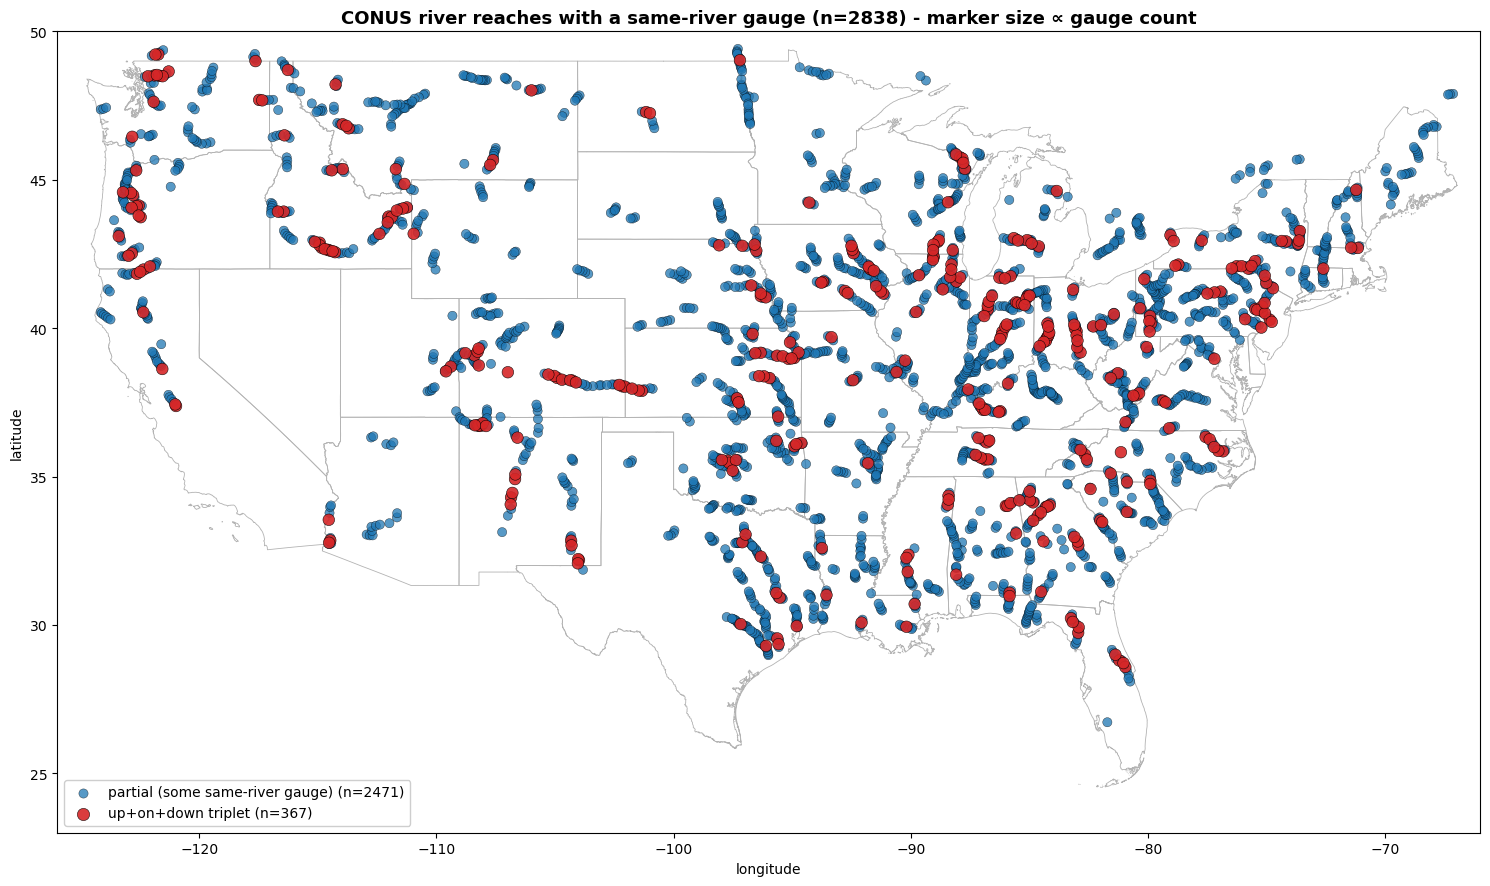

In [8]:
states = gpd.read_file(DATA/"us_states.gpkg").to_crs(4326)
if "state" in states: states = states[~states.state.isin(["AK","HI","PR","VI","GU","MP","AS"])]
d = df.copy()
d["triplet"] = (d.upstream_gauge_id != "") & (d.onreach_gauge_id != "") & (d.downstream_gauge_id != "")
fig, ax = plt.subplots(figsize=(15, 9))
states.boundary.plot(ax=ax, color="0.7", lw=0.6, zorder=1)
part = d[~d.triplet]; trip = d[d.triplet]
ax.scatter(part.lon, part.lat, s=16+14*part.n_gauges, c="#1f77b4", ec="k", lw=0.3, alpha=0.75,
           label=f"partial (some same-river gauge) (n={len(part)})", zorder=2)
ax.scatter(trip.lon, trip.lat, s=22+16*trip.n_gauges, c="#d62728", ec="k", lw=0.4, alpha=0.9,
           label=f"up+on+down triplet (n={len(trip)})", zorder=3)
ax.set_xlim(-126, -66); ax.set_ylim(23, 50); ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"CONUS river reaches with a same-river gauge (n={len(d)}) - marker size ∝ gauge count",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower left", framealpha=.95); plt.tight_layout()
savefig(fig, FIG/"conus_overview.png"); print("saved", (FIG/"conus_overview.png").relative_to(ROOT))
plt.show()

## 7 · Summary - gauge roles, gauge count, gauge span

saved output_gauge/fig/summary_gauge_roles_count_span.png


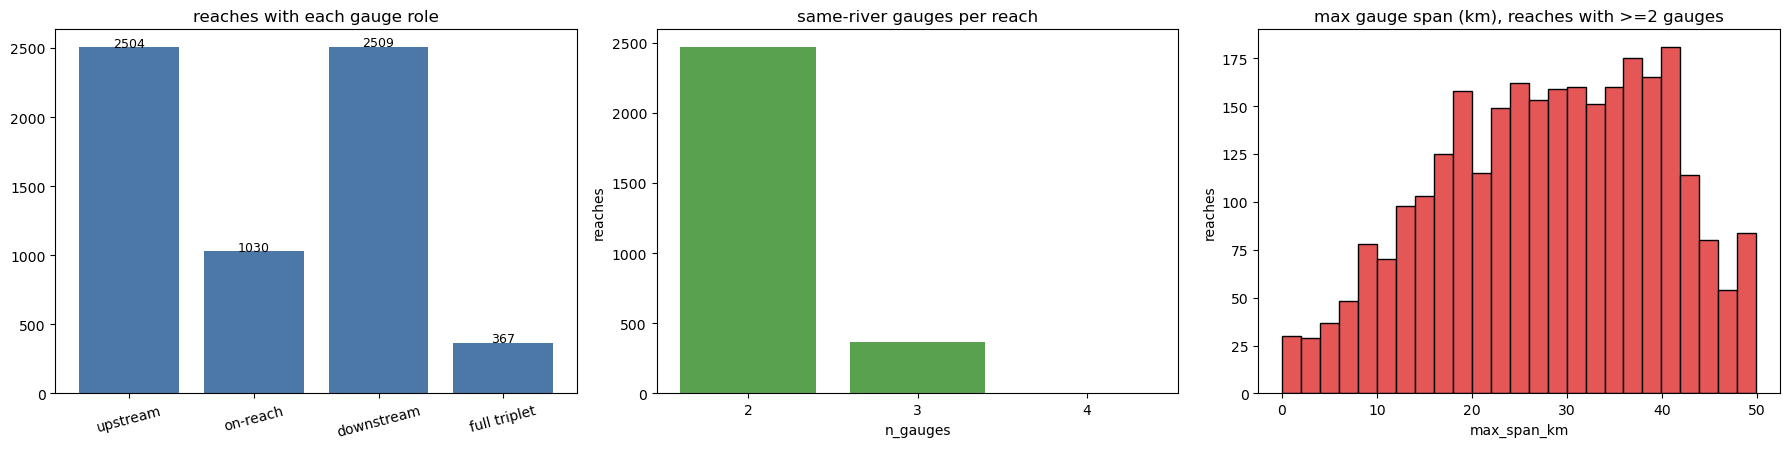

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(18, 4.6))
roles = {"upstream": (df.upstream_gauge_id!="").sum(), "on-reach": (df.onreach_gauge_id!="").sum(),
         "downstream": (df.downstream_gauge_id!="").sum(),
         "full triplet": ((df.upstream_gauge_id!="")&(df.onreach_gauge_id!="")&(df.downstream_gauge_id!="")).sum()}
axs[0].bar(list(roles), list(roles.values()), color="#4c78a8"); axs[0].set_title("reaches with each gauge role")
for i,v in enumerate(roles.values()): axs[0].text(i, v+2, str(int(v)), ha="center", fontsize=9)
axs[0].tick_params(axis="x", rotation=15)
vc = df.n_gauges.value_counts().sort_index()
axs[1].bar(vc.index.astype(str), vc.values, color="#59a14f"); axs[1].set_title("same-river gauges per reach")
axs[1].set_xlabel("n_gauges"); axs[1].set_ylabel("reaches")
sp = df[df.max_span_km > 0].max_span_km
axs[2].hist(sp, bins=25, color="#e45756", ec="k"); axs[2].set_title("max gauge span (km), reaches with >=2 gauges")
axs[2].set_xlabel("max_span_km"); axs[2].set_ylabel("reaches")
plt.tight_layout()
savefig(fig, FIG/"summary_gauge_roles_count_span.png"); print("saved", (FIG/"summary_gauge_roles_count_span.png").relative_to(ROOT))
plt.show()

## 8 · Reach + gauge maps (styled like `output_final/figures/aoi_maps_2x3.png`)

For a sample of the full-triplet reaches: the **river reach** (cyan), the **upstream / on-reach / downstream
gauges** (blue / orange / green triangles with USGS ids), plus the **same-river reaches that connect the
upstream and downstream gauges** (a second blue), over an Esri hillshade + World-Topographic basemap. So each
map shows the continuous river between the bracketing gauges, not just the middle reach. No FIMBench flood
extent (SWOT & FIMBench are out of scope here). *Saved to `output_gauge/fig/reach_gauge_maps_3x3.png`.*

In [10]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from shapely.geometry import Point
try:
    import contextily as cx, xyzservices
    HAVE_CX = True
    ESRI_HILLSHADE = xyzservices.TileProvider(name="Esri.WorldHillshade",
        url="https://server.arcgisonline.com/ArcGIS/rest/services/Elevation/World_Hillshade/MapServer/tile/{z}/{y}/{x}",
        attribution="Esri, USGS, NOAA", max_zoom=19)
except Exception as e:
    HAVE_CX = False; print("basemap libs unavailable:", e)

GLL = load_gauges().set_index("site_no")               # gauge coords (4326)
GCOL = {"upstream": "#1f77b4", "onreach": "#ff7f0e", "downstream": "#2ca02c"}
CONNECT_COL = "#2166ac"                                 # second blue for reaches linking up<->dn gauges

def _gauge_pt(site, crs):
    if site == "" or site not in GLL.index: return None
    g = GLL.loc[site]
    geom = g.geometry if hasattr(g.geometry, "x") else g.geometry.iloc[0]
    return gpd.GeoSeries([geom], crs=4326).to_crs(crs).iloc[0]

def _latlon_frame(ax, n=3, fs=10):
    xt = np.linspace(*ax.get_xlim(), n+2)[1:-1]; yt = np.linspace(*ax.get_ylim(), n+2)[1:-1]
    tx = gpd.GeoSeries([Point(x, ax.get_ylim()[0]) for x in xt], crs=3857).to_crs(4326)
    ty = gpd.GeoSeries([Point(ax.get_xlim()[0], y) for y in yt], crs=3857).to_crs(4326)
    ax.set_xticks(xt); ax.set_xticklabels([f"{p.x:.2f}°" for p in tx], fontsize=fs)
    ax.set_yticks(yt); ax.set_yticklabels([f"{p.y:.2f}°" for p in ty], fontsize=fs)

def reach_map(row, ax=None, show_legend=True, title_fs=15, annot_fs=11, tick_fs=10):
    own = ax is None
    if own: fig, ax = plt.subplots(figsize=(8.4, 8.4))
    rl = pyogrio.read_dataframe(SWORD_GPKG, where=f"reach_id = {int(row.reach_id)}").set_crs(4326, allow_override=True).to_crs(3857)
    if not len(rl): return None
    rl.plot(ax=ax, color="#00e5ff", lw=3.2, zorder=6)
    hnd = [Line2D([], [], color="#00e5ff", lw=3.2, label="study reach"),
           Line2D([], [], color=CONNECT_COL, lw=2.4, label="connecting reach")]
    b = rl.total_bounds; must = [(b[0], b[1]), (b[2], b[3])]
    # same-river reaches that connect the upstream & downstream gauges, drawn in a second blue so the
    # map shows the whole gauged path (not just the middle reach). Under the study reach (zorder 5<6).
    others = [x for x in str(row.get("connector_reach_ids", "") or "").split(";") if x and x != str(row.reach_id)]
    if others:
        try:
            ol = (pyogrio.read_dataframe(SWORD_GPKG, where="reach_id IN (" + ",".join(others) + ")")
                  .set_crs(4326, allow_override=True).to_crs(3857))
            if len(ol):
                ol.plot(ax=ax, color=CONNECT_COL, lw=2.4, zorder=5)
                cb = ol.total_bounds; must += [(cb[0], cb[1]), (cb[2], cb[3])]
        except Exception:
            pass
    for role, gid in [("upstream", row.upstream_gauge_id), ("onreach", row.onreach_gauge_id), ("downstream", row.downstream_gauge_id)]:
        p = _gauge_pt(str(gid), 3857)
        if p is None: continue
        ax.scatter(p.x, p.y, s=175, marker="^", c=GCOL[role], ec="k", zorder=7)
        ax.annotate(f"USGS {gid}", (p.x, p.y), color="white", fontsize=annot_fs, fontweight="bold",
                    xytext=(8, 6), textcoords="offset points", zorder=8,
                    path_effects=[pe.withStroke(linewidth=3, foreground="black")])
        must.append((p.x, p.y))
    cxs = (min(x for x,_ in must)+max(x for x,_ in must))/2; cys = (min(y for _,y in must)+max(y for _,y in must))/2
    half = max(max(abs(x-cxs) for x,y in must), max(abs(y-cys) for x,y in must), 3000)*1.25
    ax.set_xlim(cxs-half, cxs+half); ax.set_ylim(cys-half, cys+half)
    if HAVE_CX:
        try:
            cx.add_basemap(ax, source=ESRI_HILLSHADE, crs="EPSG:3857", attribution=False, zorder=0)
            cx.add_basemap(ax, source=cx.providers.Esri.WorldTopoMap, crs="EPSG:3857", alpha=0.6, attribution_size=4, zorder=1)
        except Exception: pass
        try: _latlon_frame(ax, fs=tick_fs)
        except Exception: pass
    hnd += [Line2D([], [], marker="^", ls="", mfc=GCOL["upstream"], mec="k", ms=11, label="upstream gauge"),
            Line2D([], [], marker="^", ls="", mfc=GCOL["onreach"], mec="k", ms=11, label="on-reach gauge"),
            Line2D([], [], marker="^", ls="", mfc=GCOL["downstream"], mec="k", ms=11, label="downstream gauge")]
    ax.set_title(f"{row.river_name} ({row.reach_id})", fontsize=title_fs)
    if show_legend: ax.legend(handles=hnd, loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=2, fontsize=10, framealpha=.95)
    if own: plt.show()
    return hnd
print("reach_map ready; HAVE_CX =", HAVE_CX, "| full-triplet reaches:", len(ready))

reach_map ready; HAVE_CX = True | full-triplet reaches: 367


### 3 × 3 grid - a sample of the full-triplet reaches (widest gauge spans)

saved output_gauge/fig/reach_gauge_maps_3x3.png


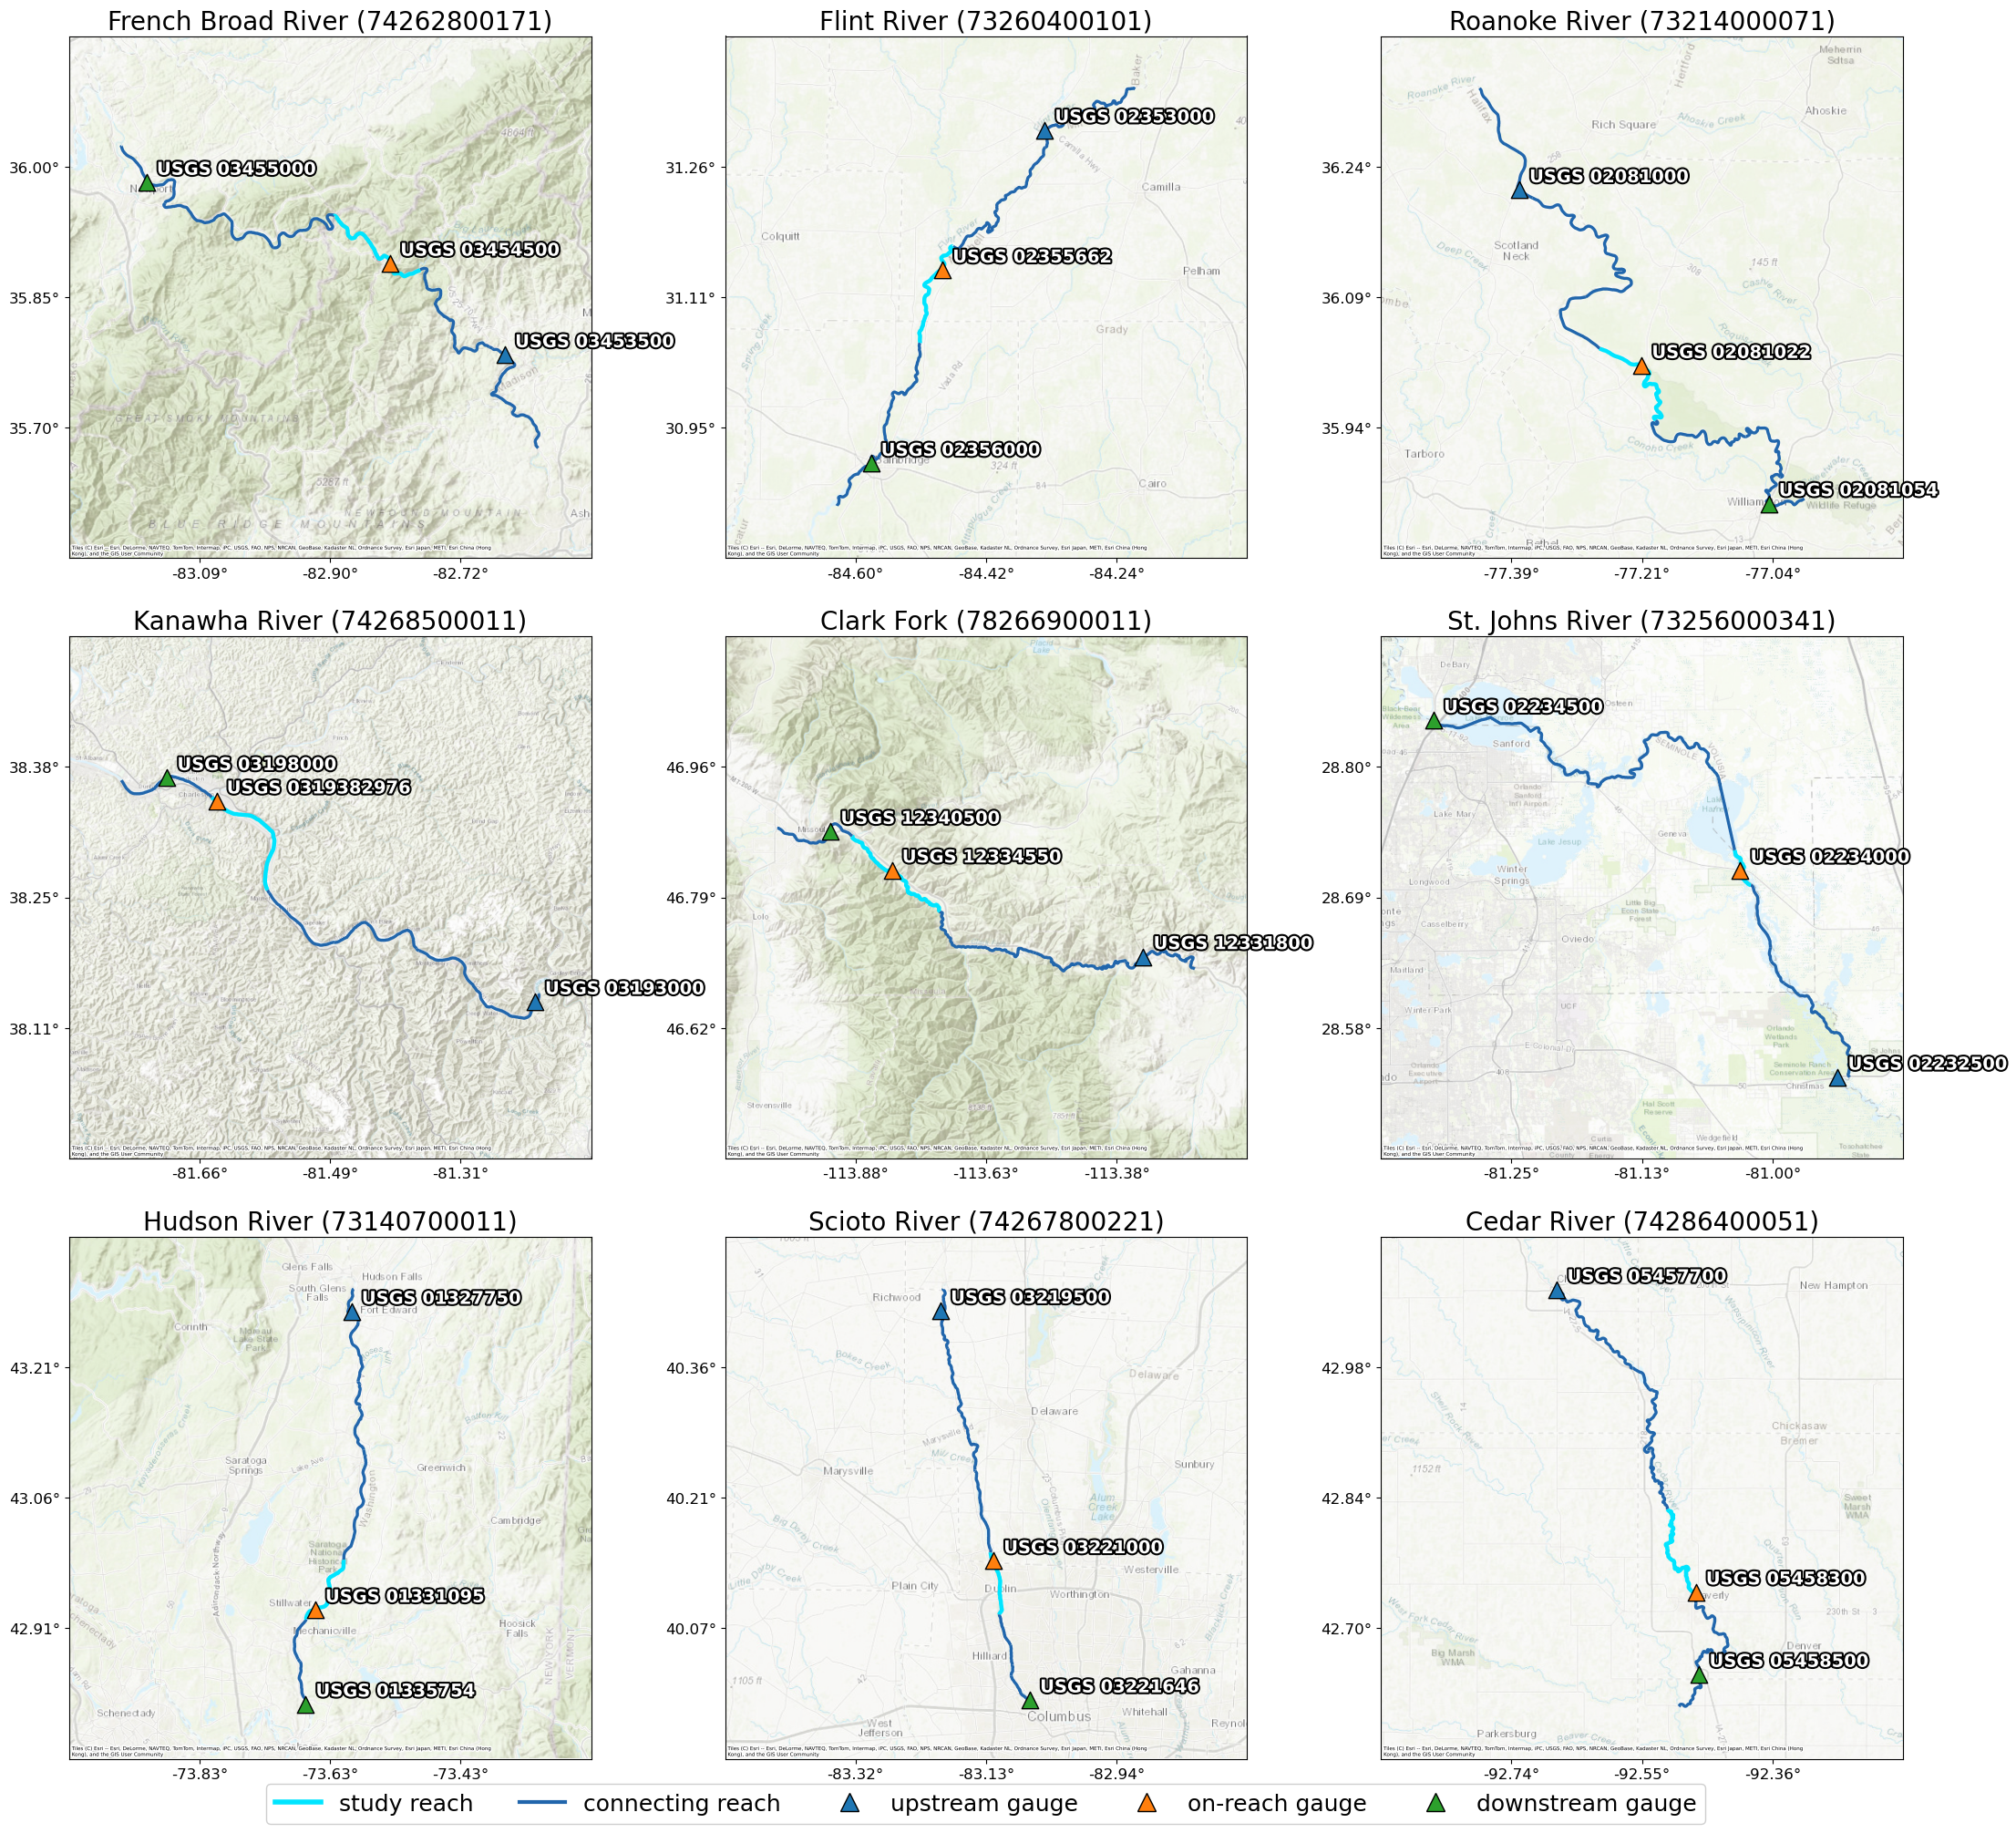

showing 9 of 367 full-triplet reaches (widest spans)


In [11]:
sel = ready.sort_values("max_span_km", ascending=False).head(9).reset_index(drop=True)
shared = [Line2D([], [], color="#00e5ff", lw=4, label="study reach"),
          Line2D([], [], color=CONNECT_COL, lw=3, label="connecting reach"),
          Line2D([], [], marker="^", ls="", mfc=GCOL["upstream"], mec="k", ms=14, label="upstream gauge"),
          Line2D([], [], marker="^", ls="", mfc=GCOL["onreach"], mec="k", ms=14, label="on-reach gauge"),
          Line2D([], [], marker="^", ls="", mfc=GCOL["downstream"], mec="k", ms=14, label="downstream gauge")]
fig, axg = plt.subplots(3, 3, figsize=(22, 21))
for ax, (_, row) in zip(axg.ravel(), sel.iterrows()):
    reach_map(row, ax=ax, show_legend=False, title_fs=20, annot_fs=14, tick_fs=12)
for ax in axg.ravel()[len(sel):]: ax.axis("off")
fig.legend(handles=shared, loc="lower center", ncol=5, bbox_to_anchor=(0.5, 0.02), fontsize=18, framealpha=.95)
fig.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.06, wspace=0.07, hspace=0.15)
savefig(fig, FIG/"reach_gauge_maps_3x3.png"); print("saved", (FIG/"reach_gauge_maps_3x3.png").relative_to(ROOT))
plt.show()
print(f"showing 9 of {len(ready)} full-triplet reaches (widest spans)")

## 9 · Stage-measurement screening - keep only gauges/reaches usable for a water-surface slope

A water-surface **slope** needs a **stage** (gage height, USGS parameter **00065**) time series at the paired
stations - a discharge-only gauge gives no water level. This section queries the USGS NWIS series catalog for
every reported station, flags whether it records stage, and applies:

* **2-station reaches** - *both* stations must have stage; otherwise the whole **reach is removed**.
* **3-station reaches (upstream + on-reach + downstream)** - checked for a valid stage pair
  (upstream&downstream, on-reach&upstream, or downstream&on-reach):
  * all three have stage &rarr; keep all three;
  * on-reach & upstream have stage but downstream does not &rarr; **remove the downstream gauge**;
  * downstream & on-reach have stage but upstream does not &rarr; **remove the upstream gauge**;
  * upstream & downstream have stage but on-reach does not &rarr; **keep all three** (the up/down pair brackets the reach, so the on-reach gauge is retained);
  * fewer than two stations have stage &rarr; **remove the reach** (no pair can form a slope).

Two tables are written under `output_gauge/table/`:
**`gauge_stage_labeled.csv`** (every candidate reach + per-station stage flags + the decision) and
**`gauge_stage_cleaned.csv`** (only surviving reaches, with disqualified stations / reaches removed). Stage
availability is cached to `gauge_stage_availability.csv`, so a re-run needs no network. Non-USGS ids (e.g.
Water-Survey-of-Canada paired gauges on transboundary rivers) are not in NWIS and count as no verifiable stage.

In [12]:
# 9.1 · stage availability from the USGS NWIS series catalog (00065 gage height), cached for offline re-runs
import time, socket
import dataretrieval.nwis as nwis
socket.setdefaulttimeout(30)                            # NWIS sets no request timeout -> guard against a stalled socket

STAGE_CSV = TAB/"gauge_stage_availability.csv"          # cache: one row per station

def station_ids(frame):
    s = set()
    for k in ("upstream_gauge_id", "onreach_gauge_id", "downstream_gauge_id"):
        s |= {str(x) for x in frame[k].fillna("") if str(x).strip() and str(x) != "nan"}
    return sorted(s)

# NWIS rejects the WHOLE request if any id is malformed -> bisect a failed group so every valid id is kept.
def _query(sites):
    for attempt in range(3):
        try:
            return nwis.get_record(sites=list(sites), service="site", seriesCatalogOutput="true", siteStatus="all")
        except Exception as e:
            if "Bad Request" in str(e) or "No sites found" in str(e): return None      # a bad id in this group
            if attempt == 2: return None
            time.sleep(2)

def _catalog(sites):
    cat = _query(sites)
    if cat is not None: return cat
    if len(sites) == 1: return None                                                    # this single id is bad
    mid = len(sites)//2
    parts = [c for c in (_catalog(sites[:mid]), _catalog(sites[mid:])) if c is not None and len(c)]
    return pd.concat(parts, ignore_index=True) if parts else None

def fetch_stage(sites, batch=100):
    "site_no -> stage/discharge availability (00065 / 00060 as a uv/dv/iv time series)."
    rows = []
    for i in range(0, len(sites), batch):
        cat = _catalog(sites[i:i+batch])
        if cat is not None and len(cat):
            cat["site_no"] = cat.site_no.astype(str); cat["parm_cd"] = cat.parm_cd.astype(str)
            for sid, sub in cat.groupby("site_no"):
                stg = sub[(sub.parm_cd == "00065") & (sub.data_type_cd.isin(["uv", "dv", "iv"]))]
                dis = sub[(sub.parm_cd == "00060") & (sub.data_type_cd.isin(["uv", "dv", "iv"]))]
                rows.append(dict(site_no=sid, in_nwis=True, has_stage=bool(len(stg)), has_discharge=bool(len(dis)),
                    stage_begin=(str(stg.begin_date.min()) if len(stg) else ""),
                    stage_end=(str(stg.end_date.max()) if len(stg) else "")))
        log(f"  stage catalog: {min(i+batch, len(sites))}/{len(sites)}")
    return pd.DataFrame(rows)

sites = station_ids(df)
cols = ["site_no", "in_nwis", "has_stage", "has_discharge", "stage_begin", "stage_end"]
avail = pd.read_csv(STAGE_CSV, dtype={"site_no": str}) if STAGE_CSV.exists() else pd.DataFrame(columns=cols)
todo = [s for s in sites if s not in set(avail.site_no.astype(str))]
log(f"stage availability: {len(sites)} stations | {len(todo)} to fetch from NWIS | {len(sites)-len(todo)} cached")
if todo:
    new = fetch_stage(todo)
    got = set(new.site_no) if len(new) else set()
    miss = pd.DataFrame([dict(site_no=s, in_nwis=False, has_stage=False, has_discharge=False,
                              stage_begin="", stage_end="") for s in todo if s not in got])   # non-NWIS ids
    avail = pd.concat([avail, new, miss], ignore_index=True).drop_duplicates("site_no")
    avail.to_csv(STAGE_CSV, index=False)
for c in ("in_nwis", "has_stage", "has_discharge"):
    avail[c] = avail[c].astype(str).str.lower().isin(["true", "1"])
STAGE = dict(zip(avail.site_no.astype(str), avail.has_stage))

def has_stage(sid):
    "True/False for a real station id; None when there is no station (blank)."
    sid = str(sid)
    return bool(STAGE.get(sid, False)) if sid.strip() and sid != "nan" else None

log(f"  stations with a stage (00065) series: {int(avail.has_stage.sum())} / {len(avail)} "
    f"| {int((~avail.in_nwis).sum())} ids not in NWIS (no verifiable stage)")
avail.head(8)

[gauge_study] stage availability: 1648 stations | 0 to fetch from NWIS | 1648 cached


[gauge_study]   stations with a stage (00065) series: 1537 / 1648 | 43 ids not in NWIS (no verifiable stage)


,site_no,in_nwis,has_stage,has_discharge,stage_begin,stage_end
0,01015800,True,True,True,2013-08-12,2026-07-09
1,01017000,True,True,True,2007-10-01,2026-07-09
2,01029100,True,True,True,2024-05-13,2026-07-09
3,01029500,True,True,True,1998-05-22,2026-07-09
4,01031500,True,True,True,2007-10-01,2026-07-09
5,01034000,True,True,True,2007-10-01,2026-07-09
6,01042500,True,True,True,2007-10-01,2026-07-09
7,01046500,True,True,True,2007-10-01,2026-07-09


In [13]:
# 9.2 · apply the keep/drop rules -> labeled CSV (all reaches) + cleaned CSV (survivors only)
_GXY = load_gauges().to_crs("EPSG:5070")                 # station coords to recompute span after a gauge is removed
GXY = {str(s): (g.x, g.y) for s, g in zip(_GXY.site_no, _GXY.geometry)}
def _span_km(ids):
    pts = [GXY[i] for i in ids if i in GXY]
    if len(pts) < 2: return 0.0
    a = np.array(pts); return float(np.max(np.linalg.norm(a[:, None, :] - a[None, :, :], axis=-1))/1000.0)

def decide(up, on, dn):
    "Return (decision, kept_up, kept_on, kept_dn, reason) from the stage rules."
    present = [g for g in (up, on, dn) if g.strip()]
    su, so, sd = has_stage(up), has_stage(on), has_stage(dn)
    if len(present) == 2:                                                     # 2-station reach: both need stage
        if all(has_stage(g) for g in present):
            return "keep_all", up, on, dn, "both stations have stage"
        return "drop_reach", "", "", "", "a station lacks stage (2-gauge reach removed)"
    cnt = sum(bool(x) for x in (su, so, sd))                                  # 3-station reach
    if cnt == 3: return "keep_all", up, on, dn, "all three stations have stage"
    if cnt <= 1: return "drop_reach", "", "", "", "fewer than two stations have stage (no valid slope pair)"
    if so and su and not sd: return "drop_downstream", up, on, "", "downstream lacks stage; keep on-reach + upstream"
    if sd and so and not su: return "drop_upstream", "", on, dn, "upstream lacks stage; keep downstream + on-reach"
    if su and sd and not so: return "keep_all", up, on, dn, "on-reach lacks stage but upstream + downstream bracket the reach; keep all three"
    return "drop_reach", "", "", "", "no valid stage pair"

lab, clean = [], []
for _, r in df.iterrows():
    up = "" if str(r.upstream_gauge_id) == "nan" else str(r.upstream_gauge_id or "")
    on = "" if str(r.onreach_gauge_id) == "nan" else str(r.onreach_gauge_id or "")
    dn = "" if str(r.downstream_gauge_id) == "nan" else str(r.downstream_gauge_id or "")
    dec, kup, kon, kdn, reason = decide(up, on, dn)
    su, so, sd = has_stage(up), has_stage(on), has_stage(dn)
    n_st = sum(bool(g) for g in (up, on, dn))
    lab.append(dict(reach_id=r.reach_id, river_name=r.river_name, n_gauges=int(r.n_gauges), n_stations=n_st,
        max_span_km=r.max_span_km, lat=r.lat, lon=r.lon,
        upstream_gauge_id=up, up_has_stage=su, onreach_gauge_id=on, on_has_stage=so,
        downstream_gauge_id=dn, dn_has_stage=sd,
        stage_up_dn=bool(su and sd), stage_on_up=bool(so and su), stage_dn_on=bool(sd and so),
        decision=dec, reason=reason))
    if dec == "drop_reach":
        continue
    surv = [g for g in (kup, kon, kdn) if g.strip()]
    clean.append(dict(reach_id=r.reach_id, n_gauges=len(surv),
        upstream_gauge_id=kup, onreach_gauge_id=kon, downstream_gauge_id=kdn,
        max_span_km=round(_span_km(surv), 2), river_name=r.river_name, lat=r.lat, lon=r.lon,
        connector_reach_ids=r.get("connector_reach_ids", ""), stage_decision=dec))

labeled = pd.DataFrame(lab); cleaned = pd.DataFrame(clean)
labeled.to_csv(TAB/"gauge_stage_labeled.csv", index=False)
cleaned.to_csv(TAB/"gauge_stage_cleaned.csv", index=False)
n_drop = int((labeled.decision == "drop_reach").sum())
print("wrote", (TAB/"gauge_stage_labeled.csv").relative_to(ROOT), f"({len(labeled)} candidate reaches, all labeled)")
print("wrote", (TAB/"gauge_stage_cleaned.csv").relative_to(ROOT),
      f"({len(cleaned)} reaches survive, {n_drop} removed)")
print("\ndecision counts:"); print(labeled.decision.value_counts().to_string())
print("\nby station count:"); print(labeled.groupby("n_stations").decision.value_counts().to_string())
labeled[["reach_id", "river_name", "n_stations", "up_has_stage", "on_has_stage", "dn_has_stage", "decision"]].head(15)

wrote output_gauge/table/gauge_stage_labeled.csv (2838 candidate reaches, all labeled)
wrote output_gauge/table/gauge_stage_cleaned.csv (2608 reaches survive, 230 removed)

decision counts:
decision
keep_all           2591
drop_reach          230
drop_downstream       9
drop_upstream         8

by station count:
n_stations  decision       
2           keep_all           2256
            drop_reach          215
3           keep_all            335
            drop_reach           15
            drop_downstream       9
            drop_upstream         8


,reach_id,river_name,n_stations,up_has_stage,on_has_stage,dn_has_stage,decision
0,74264300071,Cumberland River,3,True,True,True,keep_all
1,74266400361,White River,3,True,True,True,keep_all
2,77280400321,Gunnison River - Black Canyon Of,3,True,True,True,keep_all
3,74266400321,White River,3,True,True,True,keep_all
4,74242200411,North Canadian River,3,True,True,True,keep_all
5,72556000231,Maumee River,3,True,True,True,keep_all
6,74264300081,Cumberland River,3,True,True,True,keep_all
7,78310800191,Skagit River,3,True,True,True,keep_all
8,74300500141,Vermilion River,3,True,True,True,keep_all
9,77231000031,Colorado River,3,False,True,True,drop_upstream


saved output_gauge/fig/stage_screening_summary.png


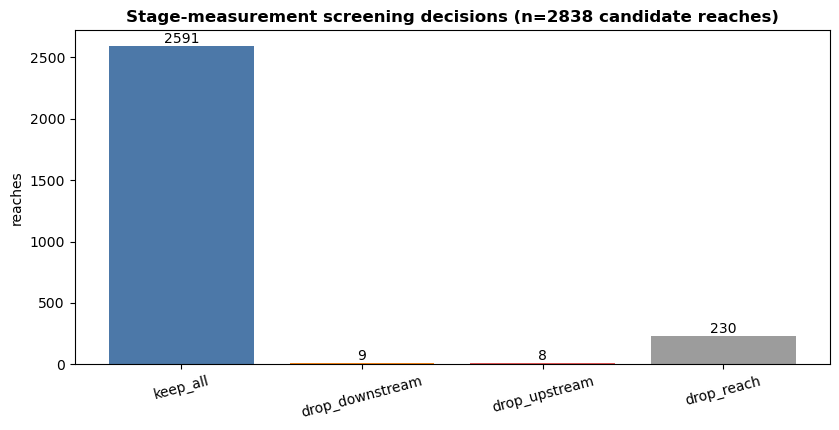

In [14]:
# 9.3 · decision summary bar (saved)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
order = ["keep_all", "drop_downstream", "drop_upstream", "drop_reach"]
vc = labeled.decision.value_counts().reindex(order).fillna(0).astype(int)
ax.bar(range(len(vc)), vc.values, color=["#4c78a8", "#f58518", "#e45756", "#9c9c9c"])
for i, v in enumerate(vc.values): ax.text(i, v + max(vc.values)*0.01, str(v), ha="center", fontsize=10)
ax.set_xticks(range(len(vc))); ax.set_xticklabels(vc.index, rotation=15); ax.set_ylabel("reaches")
ax.set_title(f"Stage-measurement screening decisions (n={len(labeled)} candidate reaches)", fontsize=12, fontweight="bold")
plt.tight_layout(); savefig(fig, FIG/"stage_screening_summary.png")
print("saved", (FIG/"stage_screening_summary.png").relative_to(ROOT)); plt.show()